## ECON-2200 Introduction to Statistics
### Shutao Cao
### Chapter 2 Examining Relationships
### 2026-09-22

We use the public use micro files (PUMFs) of the Canadian Housing Survey 2021 data.

In this survey, an observation (household) carries a weight, indicating how many Canadian households are closely similar to the household surveyed. For the purpose of this course, we ignore the weight, which means any statistics calculated here are likely **different** from those reported by Statistics Canada based on the same data set.

### Import libraries

In [31]:
import numpy as np
import pandas as pd
pd.set_option("mode.copy_on_write", True)

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
# Customize plot style sheet, rc stands for runtime configuration
mpl.rc('axes', labelsize=16)
mpl.rc('xtick', labelsize=16)
mpl.rc('ytick', labelsize=16)
plt.rc('font', size=18)
plt.rc('axes', labelsize=16, titlesize=20)
plt.rc('legend', fontsize=18)
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rcParams['lines.linewidth'] = 3.5
#plt.rcParams['axes.titlesize'] = 20
plt.rcParams["figure.figsize"] = (16/1.5, 9/1.5)  #set default figure size

### Read in CHS 2021

In [33]:
chs=pd.read_stata("~/teaching/datafiles_econ2200/2021_CHS_PUMF.dta")
chs.columns = [c.lower() for c in chs.columns]
#print(list(chs.columns))
varlist = ['pumfid','region', 'pagegr1', 'pagegr2', 'pagegr3', 'pagegr4', 'pdct_05', 'pdv_sah', 'pdv_shco', 'pdwltype', 
           'pempl', 'phhsize', 'phhttinc', 'phtype','pprov','pown_20','pown_80']
chs2 = chs.loc[:,varlist]
chs2.describe()

,pumfid,pagegr1,pagegr2,pagegr3,pagegr4,pdct_05,pdv_sah,pdv_shco,pempl,phhsize,phhttinc,pown_20,pown_80
count,40988.000000,40988.000000,40988.00000,40988.000000,40988.000000,40988.000000,40988.000000,4.098800e+04,40988.000000,40988.000000,4.098800e+04,40988.000000,4.098800e+04
mean,83994.492188,3.540231,3.58666,3.218381,3.355445,1.729067,4.460232,2.223715e+06,2.375793,15.476408,1.822736e+10,3.793305,7.451241e+07
std,11832.345703,3.074917,3.04360,3.265708,3.189827,1.447045,2.468639,4.157400e+06,2.566911,33.541870,3.860736e+10,2.459762,4.352342e+07
min,63501.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1.000000,1.000000,-6.000000e+04,1.000000,1.000000e+00
25%,73747.750000,2.000000,2.00000,1.000000,1.000000,1.000000,2.000000,6.000000e+02,1.000000,1.000000,4.200000e+04,1.000000,6.000000e+05
50%,83994.500000,2.000000,2.00000,2.000000,2.000000,1.000000,6.000000,1.200000e+03,1.000000,2.000000,8.500000e+04,2.000000,1.000000e+08
75%,94241.250000,2.000000,2.00000,2.000000,2.000000,2.000000,6.000000,3.000000e+03,2.000000,4.000000,1.900000e+05,6.000000,1.000000e+08
max,104488.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,1.000000e+07,9.000000,99.000000,1.000000e+11,9.000000,1.000000e+08


Select home owners who had mortgages in 2021

In [34]:
chs2.pown_20.unique()

array([1, 6, 9, 2], dtype=int8)

In [35]:
chs_owner = chs2[chs2.pdct_05==1]
chs_owner2 = chs_owner[chs_owner.pown_20==1]

In [36]:
# re-define missing values
chs_owner2 = chs_owner2.loc[chs_owner2.phhttinc<1000000,:]
chs_owner2 = chs_owner2.loc[chs_owner2.pown_80<1000000,:]
chs_owner2 = chs_owner2.loc[chs_owner2.phhttinc>1000,:]
chs_owner2 = chs_owner2.loc[chs_owner2.pown_80>1000,:]
chs_owner2[['phhttinc','pown_80']].describe()

,phhttinc,pown_80
count,8950.000000,8950.000000
mean,133765.502793,194411.173184
std,84834.545392,140847.429195
min,2200.000000,10000.000000
25%,80000.000000,90000.000000
50%,115000.000000,170000.000000
75%,165000.000000,260000.000000
max,975000.000000,970000.000000


### Scatterplot 
We examine the relationship between household income and the amount of mortgages for home owners.

In [37]:
chs_owner2[['phhttinc','pown_80']].head()
x=chs_owner2.loc[0:1000,'phhttinc']
y=chs_owner2.loc[0:1000,'pown_80']

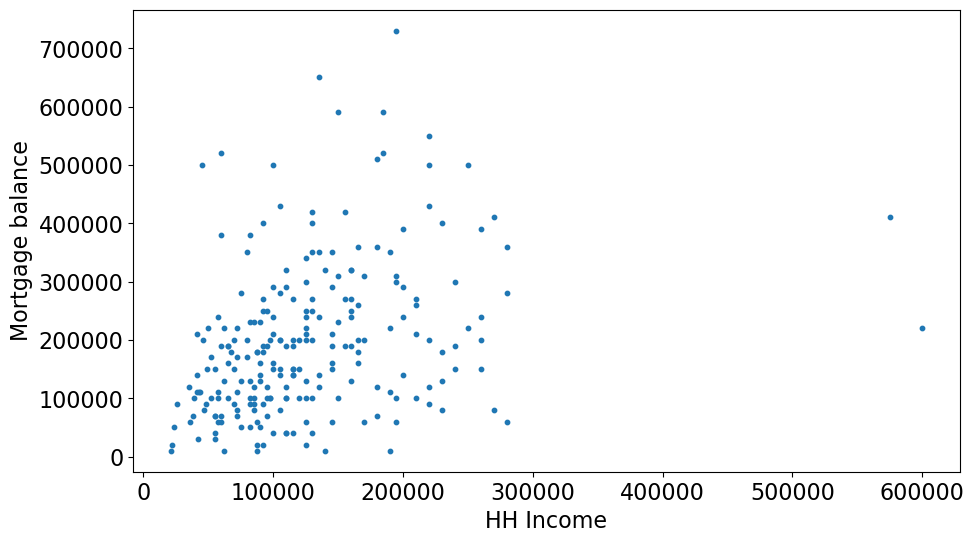

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharey='all')
ax.scatter(x,y, s=10)
ax.set_xlabel("HH Income")
ax.set_ylabel('Mortgage balance')
filename = 'mortgage.png'
plt.savefig(filename, dpi=300, format='png')
plt.show()

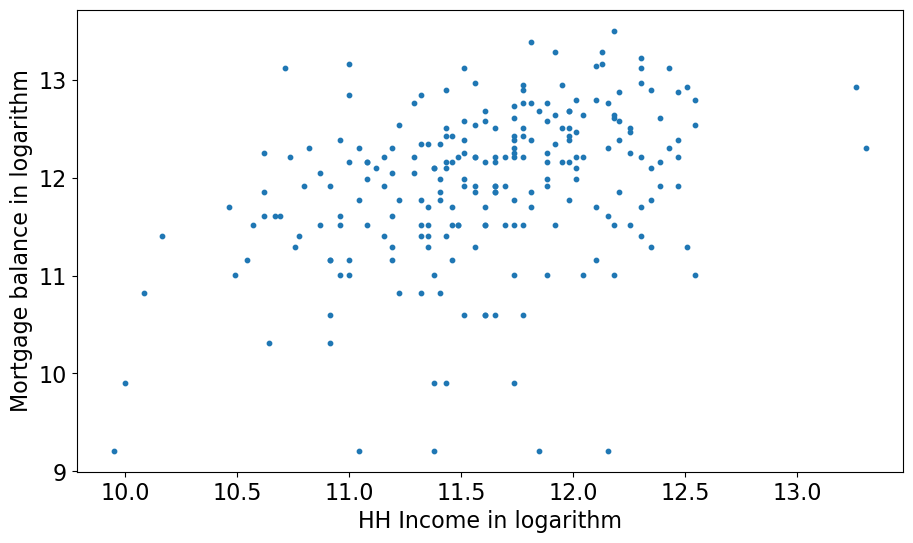

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharey='all')
ax.scatter(np.log(x),np.log(y), s=10)
ax.set_xlabel("HH Income in logarithm")
ax.set_ylabel('Mortgage balance in logarithm')
filename = 'mortgage_log.png'
plt.savefig(filename, dpi=300, format='png')
plt.show()

### Correlation
We use a small sample of males from PSID (a U.S. household survey) in 1980s, and study the relationship between the number of years of schooling and income

In [40]:
mydata = pd.read_csv("~/teaching/datafiles_econ2200/mroz1987HusbandWage.csv",header=0)
mydata.head(21)

,ID,hushrs,husage,huseduc,huswage
0,15,1694,38,12,9.1499
1,91,2246,36,12,7.5690
2,97,2280,37,17,11.4040
3,109,2100,37,17,11.6670
4,132,1936,36,12,8.7810
5,137,2058,37,13,8.2604
6,159,2200,38,9,5.4545
7,160,2033,39,12,5.9026
8,162,1626,38,14,11.6850
9,180,2390,37,13,8.7866


In [41]:
# Transform education and wages by taking natural logarithm
# Name them as x and y to make writing code simple
mydata['x'] = np.log(mydata['huseduc'])
mydata['y'] = np.log(mydata['huswage'])
mydata.describe()

,ID,hushrs,husage,huseduc,huswage,x,y
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,226.428571,2047.190476,37.380952,12.619048,8.224414,2.513298,2.074821
std,115.015030,232.464109,1.071270,2.578298,2.133092,0.220843,0.261874
min,15.000000,1626.000000,36.000000,7.000000,4.686000,1.945910,1.544579
25%,137.000000,1936.000000,37.000000,12.000000,6.678800,2.484907,1.898938
50%,195.000000,2058.000000,37.000000,13.000000,7.675400,2.564949,2.038020
75%,330.000000,2223.000000,38.000000,14.000000,9.234700,2.639057,2.222968
max,399.000000,2390.000000,39.000000,17.000000,11.864000,2.833213,2.473509


In [42]:
# correlation
mydata[['x','y']].corr()

,x,y
x,1.000000,0.701213
y,0.701213,1.000000


In [43]:
# Calculate correlation
# First, convert dataFrame to Numpy arrays
x = mydata['x'].to_numpy()
y = mydata['y'].to_numpy()
print('x=',np.round(x,2))
print('y=',np.round(y,2))

x= [2.48 2.48 2.83 2.83 2.48 2.56 2.2  2.48 2.64 2.56 2.64 2.3  2.56 1.95
 2.64 2.64 2.56 2.77 2.3  2.64 2.2 ]
y= [2.21 2.02 2.43 2.46 2.17 2.11 1.7  1.78 2.46 2.17 2.22 1.54 2.   1.8
 1.9  1.88 2.04 2.27 1.98 2.47 1.95]


In [44]:
# calculate the deviation from the mean
x_d = x - x.mean()
y_d = y - y.mean()
print('x_d=',np.round(x_d,2))
print('y_d=',np.round(y_d,2))

x_d= [-0.03 -0.03  0.32  0.32 -0.03  0.05 -0.32 -0.03  0.13  0.05  0.13 -0.21
  0.05 -0.57  0.13  0.13  0.05  0.26 -0.21  0.13 -0.32]
y_d= [ 0.14 -0.05  0.36  0.38  0.1   0.04 -0.38 -0.3   0.38  0.1   0.15 -0.53
 -0.07 -0.28 -0.18 -0.19 -0.04  0.19 -0.1   0.4  -0.13]


In [45]:
# obtain the standard deviation for x and y
x_sd = (1.0/20.0)*(np.sum(x_d**2))
s_x = np.sqrt(x_sd)
y_sd = (1.0/20.0)*(np.sum(y_d**2))
s_y = np.sqrt(y_sd)
print('s_x=',np.round(s_x,4))
print('s_y=',np.round(s_y,4))

s_x= 0.2208
s_y= 0.2619


In [46]:
# Obtain correlation
r = (1.0/20.0)*np.sum((x_d/s_x)*(y_d/s_y))
print("correlation r=", np.round(r,4))
print('Calculation leads to the same value of r as that Pandas gives!')

correlation r= 0.7012
Calculation leads to the same value of r as that Pandas gives!


#### Correlation and covariance

In [47]:
# covariance of x and y
s_xy = (1.0/20.0)*np.sum(x_d*y_d)
print('covariance s_xy=',np.round(s_xy,4))

covariance s_xy= 0.0406


In [48]:
# correlation calculated from covariance and standard deviation
r_new = s_xy / (s_x*s_y)
print("correlation r caclulated from covariance and StdDev =",np.round(r_new,4))

correlation r caclulated from covariance and StdDev = 0.7012


### Least-squares Regression
The question is to what extent 
We first calculate values of $b_0$ and $b_1$, we then plot the regression line. In doing so, we have already calculated correlation $r$, and standard deviations in the above.

In [49]:
b1 = r * s_y / s_x
b0 = y.mean() - b1*x.mean()
print('b0=',np.round(b0,4), 'and b1=',np.round(b1,4))

b0= -0.015 and b1= 0.8315


In [50]:
# check whether this is the same as Scipy gives
from scipy.stats import linregress
slope, intercept, r, p, se = linregress(x, y)
print("slope =", np.round(slope,4))
print("intercept = ", np.round(intercept,4))
print("Cross checked!")

slope = 0.8315
intercept =  -0.015
Cross checked!


In [51]:
# Predicted values of y
yhat = b0 + b1*x
print("LS-predicted y values:")
print("yhat=",np.round(yhat,2))

LS-predicted y values:
yhat= [2.05 2.05 2.34 2.34 2.05 2.12 1.81 2.05 2.18 2.12 2.18 1.9  2.12 1.6
 2.18 2.18 2.12 2.29 1.9  2.18 1.81]


In [52]:
# r-square
r_sqr = np.sum((yhat-y.mean())**2) / np.sum(y_d**2)
print(f"r-squared= {r_sqr:.4f}")
print(f"r-squared equals the correlation squared {r**2:.4f}.")
# r-squared says that the linear relationship explains 49% of variation in log wages

r-squared= 0.4917
r-squared equals the correlation squared 0.4917.


#### Plot the LS regression line

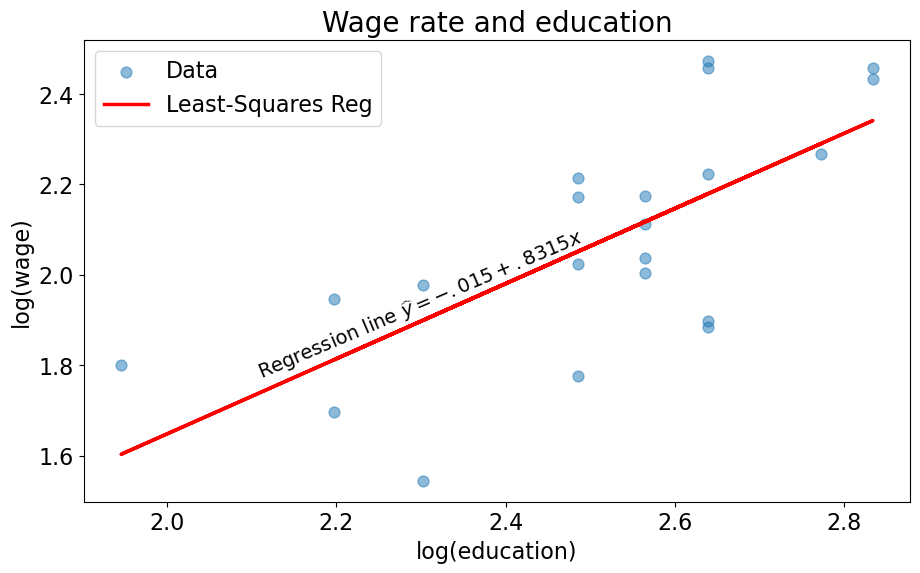

<Figure size 1066.67x600 with 0 Axes>

In [53]:
area = 10.0*(y.max())**2
fig, ax = plt.subplots(nrows=1, ncols=1,sharey='all')
ax.scatter(x, y, s=area, marker='o', alpha=0.5, label='Data')
ax.plot(x, yhat, color="red", linewidth=2.5, linestyle="-",label='Least-Squares Reg')
ax.text(2.3, 2.11, r'Regression line $\widehat{y}=-.015+.8315x$', fontsize=14,
         rotation=23,
         horizontalalignment='center',
         verticalalignment='top',
         multialignment='center')
plt.autoscale(enable=True, axis='x', tight=False)
ax.set_title('Wage rate and education', fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.xlabel("log(education)", fontsize=16)
ax.set_ylabel('log(wage)', fontsize=16)
ax.legend(loc='upper left', fontsize=16)
#fig.tight_layout()
plt.show()
plt.savefig('WageEducOLS.png',dpi=300, format='png')

#### Residuals
We check whether residuals in least-squares regression have a normal distribution.

We do that using the normal quantile plot.

In [54]:
y_res = y - yhat
print("residuals of LS are:")
print(np.round(y_res,3))

residuals of LS are:
[ 0.163 -0.027  0.093  0.116  0.121 -0.006 -0.116 -0.276  0.279  0.055
  0.044 -0.355 -0.113  0.196 -0.28  -0.296 -0.08  -0.024  0.078  0.294
  0.134]


In [55]:
# Step 1, order residuals from smallest to the largest value
y_res2 = np.sort(y_res)
print("sorted residuals",np.round(y_res2,3))

sorted residuals [-0.355 -0.296 -0.28  -0.276 -0.116 -0.113 -0.08  -0.027 -0.024 -0.006
  0.044  0.055  0.078  0.093  0.116  0.121  0.134  0.163  0.196  0.279
  0.294]


In [56]:
# Step 2, find percentile of each sorted value
from scipy import stats
y_respctile = stats.mstats.plotting_positions(y_res2, alpha=0.4, beta=0.4)
print("percentiles of residual values:")
print(np.round(y_respctile,3))

percentiles of residual values:
[0.028 0.075 0.123 0.17  0.217 0.264 0.311 0.358 0.406 0.453 0.5   0.547
 0.594 0.642 0.689 0.736 0.783 0.83  0.877 0.925 0.972]


In [57]:
# Step 3, for the same percentiles displayed above, find the normal scores, i.e., the values
# from normal distribution for corresponding percentiles
normal_scores = stats.norm.ppf(y_respctile)
print("Normal scores corresponding percentiles of residual values are:")
print(np.round(normal_scores,4))

Normal scores corresponding percentiles of residual values are:
[-1.9064 -1.4362 -1.1619 -0.9549 -0.7824 -0.6306 -0.4921 -0.3625 -0.2387
 -0.1185 -0.      0.1185  0.2387  0.3625  0.4921  0.6306  0.7824  0.9549
  1.1619  1.4362  1.9064]


To cross check the normal scores, consider the percentile 0.406. From Table A standard normal probabilities table, we see that the z value for percentile 0.406 is about -0.24, while Scipy function norm.ppf gives a value of -0.2387, very close.

One more example, consider percentile 0.689. From Table A, the z value with a percentile 0.689 is 0.49, while norm.ppf gives a value of 0.4921, very close.

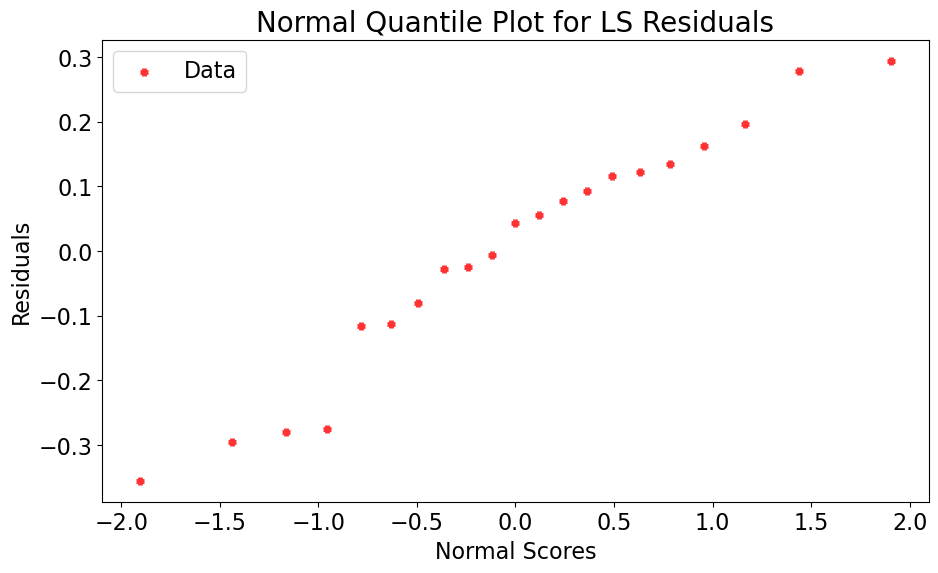

<Figure size 1066.67x600 with 0 Axes>

In [58]:
# Step 4, plot normal scores (theoretical) against the sorted least-squares residuals (data)
area = 100.0*(y_res2.max())
fig, ax = plt.subplots(nrows=1, ncols=1,sharey='all')
ax.scatter(normal_scores, y_res2, s=area, marker='+', c='r',alpha=0.8, label='Data')
#ax.plot(normal_scores, normal_scores, color="red", linewidth=2.5, linestyle="-",label='Theoretical')
plt.autoscale(enable=True, axis='x', tight=False)
ax.set_title('Normal Quantile Plot for LS Residuals', fontsize=20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.xlabel("Normal Scores", fontsize=16)
ax.set_ylabel('Residuals', fontsize=16)
ax.legend(loc='upper left', fontsize=16)
#fig.tight_layout()
plt.show()
plt.savefig('NQplot_residuals.png',dpi=300, format='png')

It is approximately a straight line, so it looks that the LS residuals very roughly have a normal distribution.